In [1]:
import numpy as np
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPModel
import oracledb
import io

# -------------------------------
# 1. Connexion à Oracle
# -------------------------------
conn = oracledb.connect(
    user="ryan",
    password="ryan23",
    dsn="localhost:1521/FREEPDB1"
)
cur = conn.cursor()


In [ ]:

# -------------------------------
# 2. Charger le modèle CLIP
# -------------------------------
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

C:\Users\DELL\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Insertion d'une image

In [ ]:

# -------------------------------
# 3. Fonction pour encoder une image en vecteur
# -------------------------------
def encode_image1(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    vec = embeddings[0].numpy()
    vec = vec / np.linalg.norm(vec)  # normalisation
    return vec.tolist()


In [20]:

# -------------------------------
# 4. Préparer l'image et le vecteur
# -------------------------------
image_path = "dataclass/chien/chien4.jpeg"  # ton image locale
vector = encode_image1(image_path)
# Convertir le vecteur en chaîne compatible TO_VECTOR()
vector_str = "[" + ",".join(map(str, vector)) + "]"

# Lire l'image en binaire pour le BLOB
with open(image_path, "rb") as f:
    image_blob = f.read()

# -------------------------------
# 5. Insérer dans Oracle
# -------------------------------
cur.execute("""
    INSERT INTO image_vectors_test (image_name, image_data, embedding)
    VALUES (:1, :2, TO_VECTOR(:3))
""", ("chien.jpg", image_blob, vector_str))

conn.commit()
print("Image + embedding insérés avec succès")

cur.close()
conn.close()


Image + embedding insérés avec succès


In [5]:
import os

Insertion d'un fichier d'image 

In [10]:
import os
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import oracledb

# -------------------------------
# 1. Connexion Oracle
# -------------------------------
conn = oracledb.connect(
    user="ryan",
    password="ryan23",
    dsn="localhost:1521/FREEPDB1"
)
cur = conn.cursor()

# -------------------------------
# 2. Charger le modèle CLIP
# -------------------------------
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


In [3]:

# -------------------------------
# 3. Encoder une image → vecteur
# -------------------------------
def encode_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    # Normalisation du vecteur
    vector = embeddings[0].numpy()
    vector = vector / np.linalg.norm(vector)
    return vector.tolist()  # convertir en liste Python


In [7]:

# -------------------------------
# 4. Parcourir le dossier d’images
# -------------------------------
folder_path = "DRD Dataset"  # dossier contenant tes images
for filename in os.listdir(folder_path):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(folder_path, filename)
        try:
            # Encoder en vecteur
            vec = encode_image(img_path)
            vector_str = "[" + ",".join(map(str, vec)) + "]"

            # Lire l’image en binaire
            with open(img_path, "rb") as f:
                img_blob = f.read()

            # Insertion dans Oracle
            cur.execute("""
                INSERT INTO Diabetic_Retinopathy_Diagnosis (image_name, embedding, image_data)
                VALUES (:1, TO_VECTOR(:2), :3)
            """, (filename, vector_str, img_blob))

            #print("image + vecteur insérés avec succès")
        except Exception as e:
            print(f"[ERREUR] {filename} : {e}")

conn.commit()
cur.close()
conn.close()

[ERREUR] 20170412202800866.jpg : image file is truncated (58 bytes not processed)


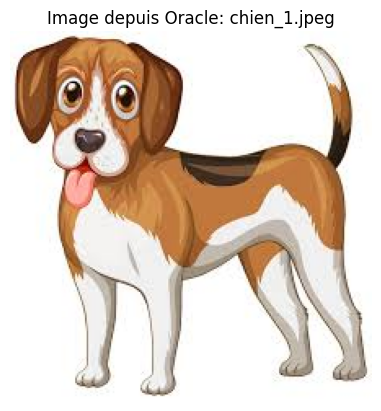

In [25]:
import oracledb
from PIL import Image
import io
import matplotlib.pyplot as plt

# Connexion
conn = oracledb.connect(
    user="ryan",
    password="ryan23",
    dsn="localhost:1521/FREEPDB1"
)
cur = conn.cursor()

# Requête
cur.execute("""
    SELECT image_name, image_data 
    FROM image_vectors 
    WHERE image_id = :1
""", (7,))  # récupérer l'image avec ID=5

row = cur.fetchone()
if row:
    name, blob = row

    # Lire le contenu du BLOB
    if hasattr(blob, "read"):
        data = blob.read()
    else:
        data = blob
    # Sauvegarde
    #with open(f"retrieved_{name}", "wb") as f:
    #    f.write(data)
    
    # Convertir les bytes en image
    image = Image.open(io.BytesIO(data))

    # Afficher l'image
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image depuis Oracle: {name}")
    plt.show()
else:
    print("❌ Aucun enregistrement trouvé.")
